In [1]:
from sunflower.utils import setup_notebook

setup_notebook(
    device=1,
    tmp_dir="/local/scratch/carlyn.1/tmp",
    hf_cache_dir="/local/scratch/carlyn.1/hf_cache"
)

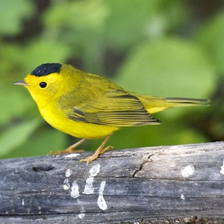

In [2]:
from PIL import Image

image = Image.open("../../assets/sunflower_1.JPG").resize((224, 224))
x = 410
y = 200
w = 300
h = 300
image = Image.open("../../output.png").crop((x, y, x + w, y + h)).resize((224, 224))
image

In [3]:
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# Load the model
model = build_sam3_image_model(enable_inst_interactivity=True)
processor = Sam3Processor(model)
# Load an image
inference_state = processor.set_image(image)
# Prompt the model with text
output = processor.set_text_prompt(state=inference_state, prompt="a bird")

# Get the masks, bounding boxes, and scores
masks, boxes, scores = output["masks"], output["boxes"], output["scores"]

/home/carlyn.1/code/sunflower/.venv/lib/python3.12/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/carlyn.1/code/sunflower/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print(len(masks))

1


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        print(mask.shape)
        if isinstance(mask, torch.Tensor):
            mask = mask.cpu().numpy()[0]
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

1
torch.Size([1, 224, 224])


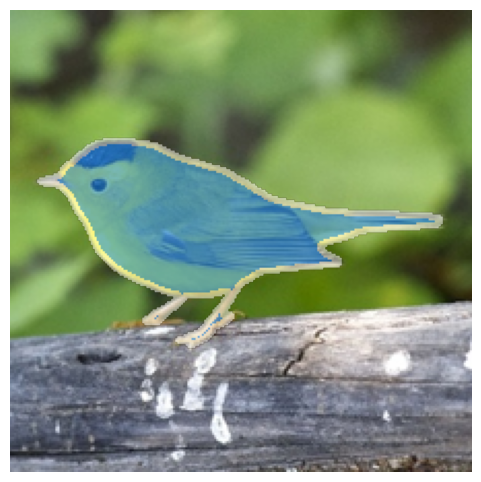

In [6]:
print(len(masks))

show_masks(image, masks, scores, input_labels=["a bird"])

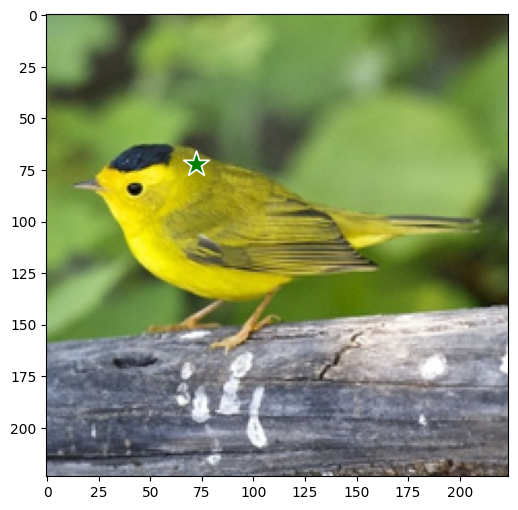

In [12]:
#input_point = np.array([[46, 68], [66, 88]])
input_point = np.array([[72, 72]])
input_label = np.array([1])

plt.figure(figsize=(6, 6))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()  

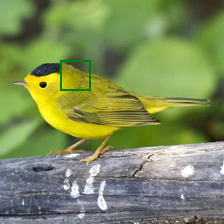

In [28]:
from PIL import ImageDraw

x = 60
y = 60
w = 30
h = 30

draw_img = image.copy()
draw = ImageDraw.Draw(draw_img)
draw.rectangle([x, y, x + w, y + h], outline="green", width=2)

draw_img

In [31]:
inference_state = processor.set_image(image)

masks, scores, logits = model.predict_inst(
    inference_state,
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
    box=np.array([x, y, x + w, y + h]),
)
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]

torch.Size([1, 256, 72, 72])


(224, 224)


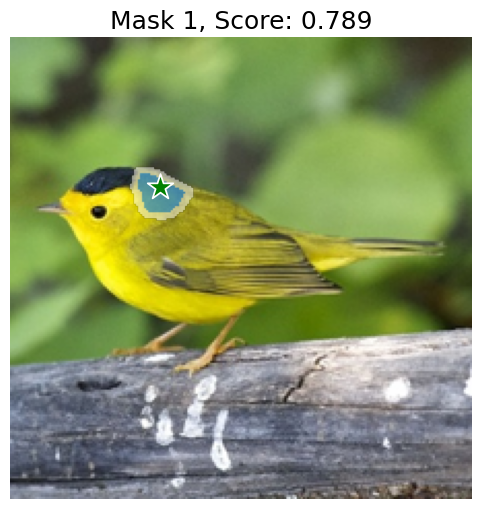

(224, 224)


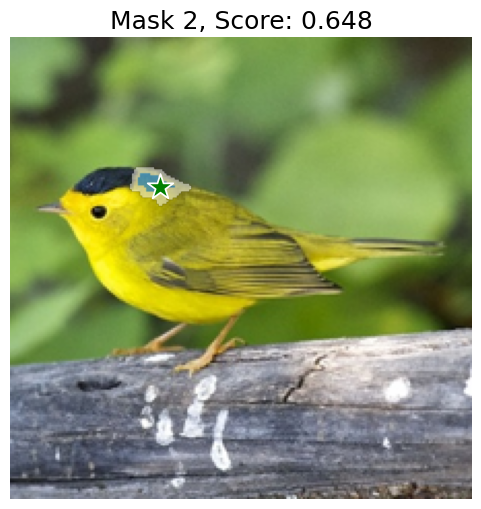

(224, 224)


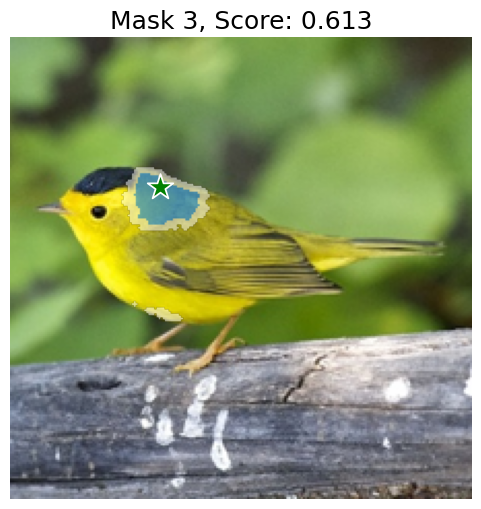

In [32]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)